In [27]:
import os
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
attacks_dir = "/home/c01saha/CISPA-projects/agrauq-2024/EvaAttack/reports"
attack_files = {
    "1": "EvAttackAccelerated-e8a5712687-eps_0_1-GCN-5a6438363a-ind-cora_ml-cora_ml-346ba86faf.pt--",
    "0.1": "EvAttackAccelerated-ceaa495691-eps_0_1-GCN-5a6438363a-ind-cora_ml-cora_ml-346ba86faf.pt--",
    "0.5": "EvAttackAccelerated-11ff1e2898-eps_0_1-GCN-5a6438363a-ind-cora_ml-cora_ml-346ba86faf.pt--",
    "10.0": "EvAttackAccelerated-bd08793a85-eps_0_1-GCN-5a6438363a-ind-cora_ml-cora_ml-346ba86faf.pt--",
    "50.0": "EvAttackAccelerated-daa38ffd26-eps_0_1-GCN-5a6438363a-ind-cora_ml-cora_ml-346ba86faf.pt--",
}

In [29]:
plt.set_cmap("viridis")

<Figure size 432x288 with 0 Axes>

In [30]:
debug_files = {}
debug_tracks = {}
for key, file_name in attack_files.items():
    debug_files[key] = torch.load(os.path.join(attacks_dir, f"{file_name}.pt"))["debug_info"]
    debug_tracks[key] = torch.stack([item["evals"] for item in debug_files[key]])

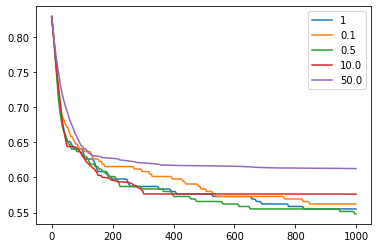

In [31]:
for key, track in debug_tracks.items():
    sns.lineplot(track.mean(dim=1), label=key)

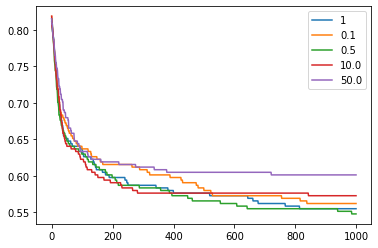

In [32]:
for key, track in debug_tracks.items():
    sns.lineplot(track.min(dim=1)[0], label=key)


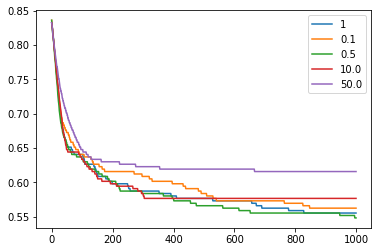

In [33]:
for key, track in debug_tracks.items():
    sns.lineplot(track.max(dim=1)[0], label=key)


In [7]:
attack_files

{'1': 'EvAttackAccelerated-e8a5712687-eps_0_1-GCN-5a6438363a-ind-cora_ml-cora_ml-346ba86faf.pt--',
 '0.1': 'EvAttackAccelerated-ceaa495691-eps_0_1-GCN-5a6438363a-ind-cora_ml-cora_ml-346ba86faf.pt--',
 '10.0': 'EvAttackAccelerated-bd08793a85-eps_0_1-GCN-5a6438363a-ind-cora_ml-cora_ml-346ba86faf.pt--',
 '50.0': 'EvAttackAccelerated-daa38ffd26-eps_0_1-GCN-5a6438363a-ind-cora_ml-cora_ml-346ba86faf.pt--'}

In [3]:
subgraph_2_debug = torch.load(os.path.join(attacks_dir, f"{subgraph_2_file}.pt"))["debug_info"]
subgraph_2_track = torch.stack([item["evals"] for item in subgraph_2_debug])

In [4]:
normal_debug = torch.load(os.path.join(attacks_dir, f"{normal_file}.pt"))["debug_info"]
normal_track = torch.stack([item["evals"] for item in normal_debug])

In [5]:
adaptive_debug = torch.load(os.path.join(attacks_dir, f"{adaptive_file}.pt"))["debug_info"]
adaptive_track = torch.stack([item["evals"] for item in adaptive_debug])

<AxesSubplot:>

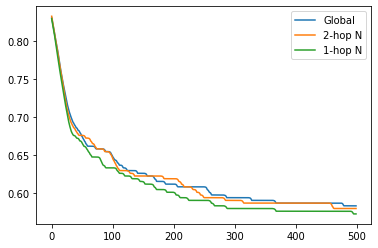

<AxesSubplot:>

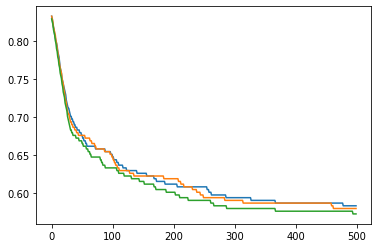

In [7]:
sns.lineplot(normal_track.quantile(q=0.5, dim=1))
sns.lineplot(subgraph_2_track.quantile(q=0.5, dim=1))
sns.lineplot(adaptive_track.quantile(q=0.5, dim=1))

<AxesSubplot:>

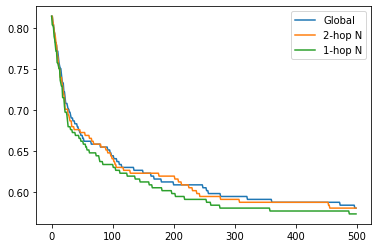

In [8]:
sns.lineplot(normal_track.min(dim=1)[0], label="Global")
sns.lineplot(subgraph_2_track.min(dim=1)[0], label="2-hop N")
sns.lineplot(adaptive_track.min(dim=1)[0], label="1-hop N")

In [31]:
normal_track.min(dim=1)

torch.return_types.min(
values=tensor([0.8149, 0.8149, 0.8078, 0.8043, 0.7972, 0.7936, 0.7829, 0.7829, 0.7794,
        0.7722, 0.7722, 0.7651, 0.7580, 0.7544, 0.7509, 0.7509, 0.7438, 0.7367,
        0.7331, 0.7331, 0.7224, 0.7224, 0.7153, 0.7082, 0.7082, 0.7082, 0.7046,
        0.7011, 0.7011, 0.6975, 0.6975, 0.6940, 0.6904, 0.6904, 0.6904, 0.6868,
        0.6868, 0.6868, 0.6833, 0.6833, 0.6833, 0.6833, 0.6797, 0.6797, 0.6762,
        0.6762, 0.6726, 0.6726, 0.6690, 0.6690, 0.6690, 0.6655, 0.6655, 0.6619,
        0.6619, 0.6619, 0.6619, 0.6619, 0.6619, 0.6619, 0.6619, 0.6619, 0.6619,
        0.6619, 0.6619, 0.6584, 0.6584, 0.6584, 0.6584, 0.6584, 0.6584, 0.6584,
        0.6584, 0.6584, 0.6584, 0.6584, 0.6584, 0.6584, 0.6584, 0.6584, 0.6548,
        0.6548, 0.6548, 0.6548, 0.6548, 0.6548, 0.6548, 0.6548, 0.6548, 0.6548,
        0.6548, 0.6548, 0.6512, 0.6512, 0.6512, 0.6512, 0.6477, 0.6477, 0.6441,
        0.6441, 0.6441, 0.6441, 0.6406, 0.6406, 0.6406, 0.6406, 0.6406, 0.6370,
        0

In [ ]:
mainfile = "GCN-5a6438363a-ind-cora_ml-cora_ml-346ba86faf.pt"
main_acc = 0.8375494071146244

In [3]:
# General configs: dataset name, model name, etc.
dataset_name = "cora_ml"
model_name = "GCN"
n_runs = 5 # TODO: previously it was n_splits.
inductive = True 

# Configs for splits 
training_nodes = None # number of training nodes (if integer it should be per-class)
validation_nodes = None 
training_split_type = None # it is either "stratified" or "non-stratified"
validation_split_type = None
test_nodes = None
test_split_type = None

model_configs = None # it is a dictionary of model parameters
retrain_models = False

attack_name = "EvAttack"
attack_configs = None
epsilon = 0.1


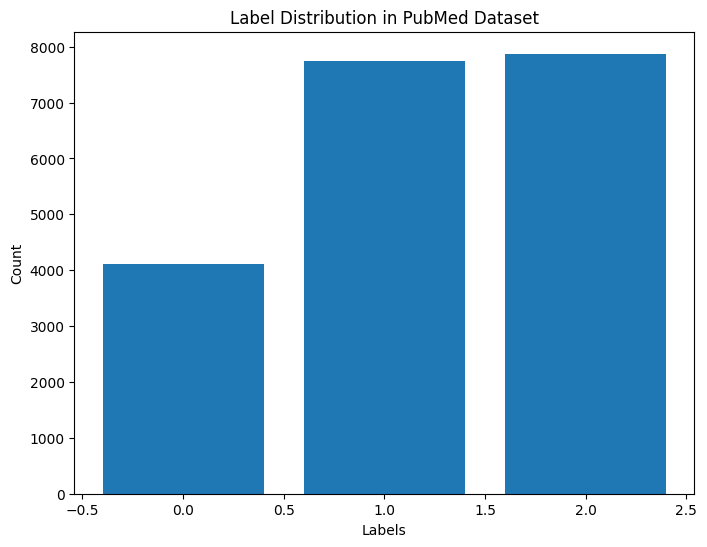

In [83]:
import torch
from torch_geometric.datasets import Planetoid
import matplotlib.pyplot as plt

# Load the PubMed dataset
dataset = Planetoid(root='/tmp/PubMed', name='PubMed')

# Access the dataset
data = dataset[0]

# Get the labels
labels = data.y

# Count the frequency of each label
unique_labels, counts = torch.unique(labels, return_counts=True)

# Plot the label distribution
plt.figure(figsize=(8, 6))
plt.bar(unique_labels.numpy(), counts.numpy())
plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Label Distribution in PubMed Dataset')
plt.show()
